# Gravitational-Wave Turbulence Spectra Explorer

Based on the [BK2016](https://arxiv.org/abs/1607.01360) self-similar scaling $E(k\xi(t),t) = \xi^{-\beta}\,\phi(k\xi)$ with $\xi \propto t^q$.
Total energy decays as $\mathcal{E}(t)\propto(1+t/t_1)^{-p}$.  
s= 4 in this case
## Piecewise spectrum
$$
E(k,t)=
\begin{cases}
C\, k^{s}, & k < k_0(t) \\
C'\, k^{-5/3}, & k > k_0(t)
\end{cases}
$$

**First constant**: $C = 1$.  
**Second constant**: $C' = k_0(t)^{\,s + 5/3}.$ (Continuity)

## Peak wavenumber evolution
| $\beta$ | $q$ | $p$ | $k_0(t)$ |
|---------|-----|-----|----------|
| 4 | 2/7 | 10/7 | $k_0(t_0)\left(1+t/t_1\right)^{-2/7}$ |
| 1 | 1/2 | 1   | $k_0(t_0)\left(1+t/t_1\right)^{-1/2}$ |
| 0 | 2/3 | 2/3 | $k_0(t_0)\left(1+t/t_1\right)^{-2/3}$ |

Total energy decays as $\mathcal{E}(t)\propto(1+t/t_1)^{-p}$.  

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, FloatLogSlider, FloatSlider, Dropdown, fixed
from IPython.display import display

%matplotlib widget

plt.rcParams.update({'figure.dpi': 100, 'font.size': 20})


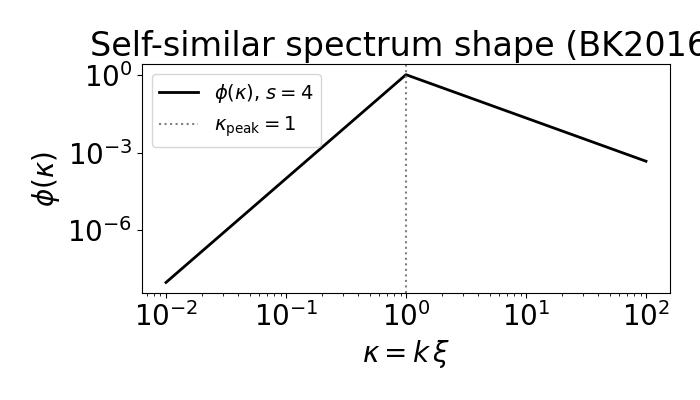

Continuity check at kappa=1: phi(1-)/phi(1+) = 0.994639


In [38]:
def phi_spectrum(kappa, s=4, kappa_peak=1.0):
    """
    Self-similar shape  phi(kappa): k^s below peak, k^{-5/3} above (Kolmogorov).
    Continuity at kappa_peak:  C' = kappa_peak^{s + 5/3}.
    """
    kappa = np.asarray(kappa, dtype=float)
    C_prime = kappa_peak ** (s + 5 / 3)
    return np.where(kappa < kappa_peak, kappa**s, C_prime * kappa**(-5 / 3))


def xi_t(t, q, t1=1.0):
    """
    Normalised integral scale  xi(t)/xi(0) = (1 + t/t1)^q.
    """
    return (1.0 + t / t1) ** q


def E_spectrum(k, t, beta, q_exp, k0_init=1.0, t1=1.0, s=4):
    """
    BK2016 self-similar energy spectrum
       E(k,t) = xi(t)^{-beta}  phi(k * xi(t) / k0_init)
    Physical peak is at  k0(t) = k0_init / xi(t).
    """
    xi = xi_t(t, q_exp, t1)
    kappa = k * xi / k0_init
    return xi ** (-beta) * phi_spectrum(kappa, s=s, kappa_peak=1.0)


def k_peak_t(t, k0_init, q_exp, t1=1.0):
    """
    Peak wavenumber  k0(t) = k0_init * (1 + t/t1)^{-q}.
    """
    return k0_init / xi_t(t, q_exp, t1)


def E_at_peak(t, k0_init, beta, q_exp, t1=1.0, s=4):
    """
    Spectrum amplitude evaluated at the peak k0(t).
    """
    kp = k_peak_t(t, k0_init, q_exp, t1)
    return E_spectrum(kp, t, beta, q_exp, k0_init, t1, s)


kappa_test = np.logspace(-2, 2, 2000)
phi_test   = phi_spectrum(kappa_test, s=4, kappa_peak=1.0)

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(kappa_test, phi_test, 'k-', lw=2, label=r'$\phi(\kappa)$, $s=4$')
ax.axvline(1.0, ls=':', color='gray', label=r'$\kappa_{\rm peak}=1$')
ax.set_xlabel(r'$\kappa = k\,\xi$')
ax.set_ylabel(r'$\phi(\kappa)$')
ax.set_title('Self-similar spectrum shape (BK2016)')
ax.legend(fontsize=14)
plt.tight_layout()
plt.show()
print(f"Continuity check at kappa=1: phi(1-)/phi(1+) = {phi_test[999]/phi_test[1000]:.6f}")


## Decay classes (BK2016 Table I)

$$\beta = \frac{2}{q}-3, \qquad p = (1+\beta)\,q, \qquad \text{self-similarity line: } p=2(1-q).$$

| Class | $\beta$ | $q$ | $p$ | Physical invariant |
|---|---|---|---|---|
| HD (Loitsiansky) | 4 | 2/7 = 0.29 | 10/7 = 1.43 | Loitsiansky integral $\mathcal{L}$ |
| HD (Saffman) | 3 | 1/3 = 0.33 | 4/3 = 1.33 | Saffman integral |
| nonhelical MHD | 1 | 1/2 = 0.50 | 1 | $\langle A_{\rm 2D}^2\rangle$ |
| helical MHD | 0 | 2/3 = 0.67 | 2/3  = 0.67 | magnetic helicity $\langle\mathbf{A}\cdot\mathbf{B}\rangle$ |


In [39]:
CLASSES = {
    'HD  β=4  (Loitsiansky)':  dict(beta=4, q=2/7,  p=10/7, color='steelblue',  ls='-'),
    'HD  β=3  (Saffman)':      dict(beta=3, q=1/3,  p=4/3,  color='royalblue',  ls='--'),
    'nonhelical MHD  β=1':     dict(beta=1, q=1/2,  p=1.0,  color='darkorange', ls='-'),
    'helical MHD  β=0':        dict(beta=0, q=2/3,  p=2/3,  color='crimson',    ls='-'),
}

print(f"{'Class':<30} {'beta':>5}  {'q':>8}  {'p':>8}  check: beta=2/q-3")
print("-" * 68)
for name, c in CLASSES.items():
    beta_check = 2 / float(c['q']) - 3
    print(f"{name:<30} {c['beta']:>5}  {c['q']:>8.4f}  {c['p']:>8.4f}  {beta_check:>8.4f}")


Class                           beta         q         p  check: beta=2/q-3
--------------------------------------------------------------------
HD  β=4  (Loitsiansky)             4    0.2857    1.4286    4.0000
HD  β=3  (Saffman)                 3    0.3333    1.3333    3.0000
nonhelical MHD  β=1                1    0.5000    1.0000    1.0000
helical MHD  β=0                   0    0.6667    0.6667    0.0000


## Interactive spectrum explorer

Use the widgets to choose a decay class and explore how $E(k,t)$ evolves.

- **Left panel**: $E(k,t)$ at the selected time $t/t_1$. Faint grey curves show the spectrum at
  logarithmically-spaced earlier times. The coloured dot marks the spectral peak $(k_0(t), E_{\rm peak}(t))$
  and the coloured trail traces its path from $t=0$.
- **Right panel**: Compensated spectrum $\xi(t)^\beta\,E(k,t)$ vs $k\xi(t)$, showing how the
  self-similar collapse onto $\phi(\kappa)$ works at different times.


/tmp/ipykernel_119805/2141617080.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  _ax.legend(fontsize=10, loc='lower left')


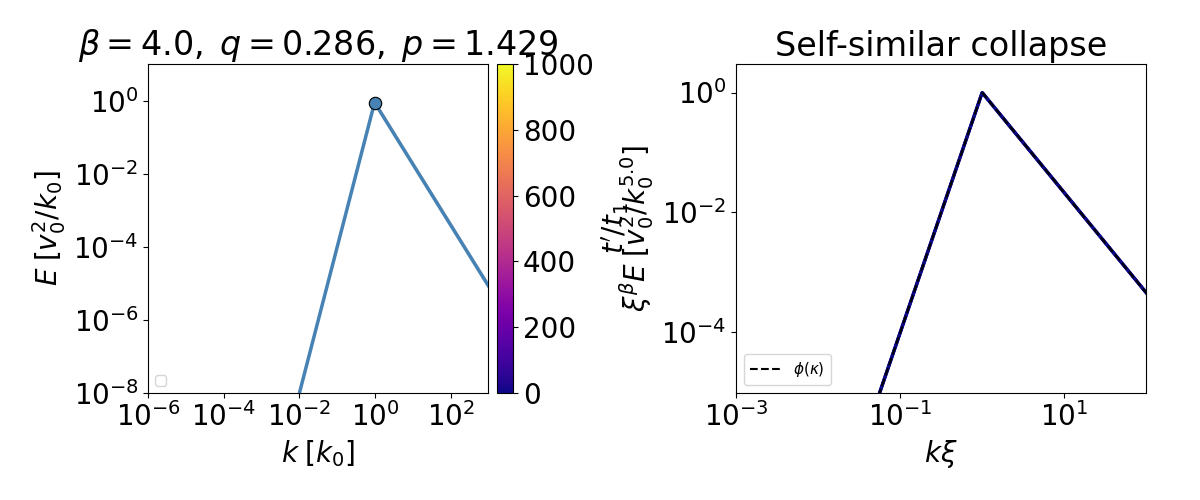

In [40]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.collections import LineCollection
import matplotlib.cm as cm

k_grid  = np.logspace(-6, 3, 1500)
T_MAX   = 1e3
N_TRAIL = 200
N_GHOST = 8
N_COMP  = 7
s       = 4

_norm = Normalize(vmin=0, vmax=T_MAX)
_cmap = cm.plasma #type: ignore

# ── Build figure once ────────────────────────────────────────────────────────
_fig2, (_ax, _ax2) = plt.subplots(1, 2, figsize=(12, 5))
_fig2.canvas.header_visible = False #type: ignore

# Left panel — static artists
_ghost_lines = [_ax.loglog([], [], '-', color='0.82', lw=0.8, zorder=1)[0]
                for _ in range(N_GHOST)]
_main_line,  = _ax.loglog([], [], '-', lw=2.5, zorder=3)
_trail_lc    = LineCollection([], cmap=_cmap, norm=_norm, lw=2, zorder=2)
_ax.add_collection(_trail_lc)
_peak_dot    = _ax.scatter([], [], s=80, zorder=5, edgecolors='k', lw=0.8)

_ax.set_xlabel(r'$k\;[k_0]$')
_ax.set_ylabel(r'$E\;[v_0^2/k_0]$')
_ax.set_xlim(k_grid[0], k_grid[-1])
_ax.set_ylim(1e-8, 10)
_ax.set_xscale('log')
_ax.set_yscale('log')
_ax_title = _ax.set_title('')
_ax.legend(fontsize=10, loc='lower left')

sm = ScalarMappable(cmap=_cmap, norm=_norm)
sm.set_array([])
_cb = _fig2.colorbar(sm, ax=_ax, pad=0.02)
_cb.set_label(r"$t'/t_1$")

phi_ref   = phi_spectrum(k_grid, s=s, kappa_peak=1.0)
_ref_line, = _ax2.loglog(k_grid, phi_ref, 'k--', lw=1.5, label=r'$\phi(\kappa)$', zorder=5)
_comp_lines = [_ax2.loglog([], [], '-', lw=1.0)[0] for _ in range(N_COMP)]

_ax2.set_xlabel(r'$k\xi$')          # dimensionless — no unit bracket
_ax2.set_ylabel('')                  # filled in _update with correct β
_ax2.set_title(r'Self-similar collapse')
_ax2.set_xlim(1e-3, 1e2)
_ax2.set_ylim(phi_ref.max() * 1e-5, phi_ref.max() * 3)
_ax2.set_xscale('log')
_ax2.set_yscale('log')
_ax2.legend(fontsize=11, loc='lower left')

_fig2.tight_layout()


def _update(change=None):
    t     = 10 ** w_logt.value
    k0    = 10 ** w_logk0.value
    cls   = CLASSES[w_class.value]
    beta  = float(cls['beta'])
    q_exp = float(cls['q'])
    color = cls['color']

    # live readouts
    w_t_out.value  = fr"  $t/t_1$ = {t:.3g}"
    w_k0_out.value = fr"  $k_0$ = {k0:.3g} [$k_0$]   \xi_0 = {1/k0:.3g} [$k_0^{-1}$]"

    exp = beta + 1
    if exp == 1:
        _ax2.set_ylabel(r'$\xi^\beta E\;[v_0^2/k_0]$')
    else:
        _ax2.set_ylabel(fr'$\xi^\beta E\;[v_0^2/k_0^{{{exp}}}]$')

    t_snaps = np.logspace(-2, np.log10(max(t, 0.011)), N_GHOST)
    for i, gl in enumerate(_ghost_lines):
        if i < N_GHOST - 1:
            gl.set_data(k_grid, E_spectrum(k_grid, t_snaps[i], beta, q_exp, k0, s=s))
        else:
            gl.set_data([], [])

    # main spectrum
    _main_line.set_data(k_grid, E_spectrum(k_grid, t, beta, q_exp, k0, s=s))
    _main_line.set_color(color)

    t_trail  = np.linspace(0.0, t, N_TRAIL)
    xi_trail = xi_t(t_trail, q_exp)
    kp_trail = k0 / xi_trail
    Ep_trail = xi_trail ** (-beta)
    pts  = np.column_stack([kp_trail, Ep_trail])
    segs = np.stack([pts[:-1], pts[1:]], axis=1)
    _trail_lc.set_segments(segs)
    _trail_lc.set_array(t_trail[:-1])

    _peak_dot.set_offsets([[kp_trail[-1], Ep_trail[-1]]])
    _peak_dot.set_facecolor(color)

    _ax_title.set_text(fr'$\beta={beta},\;q={q_exp:.3f},\;p={cls["p"]:.3f}$')


    t_comp = np.logspace(-2, np.log10(max(t, 0.011)), N_COMP)
    for i_t, (t_c, cl) in enumerate(zip(t_comp, _comp_lines)):
        xi      = xi_t(t_c, q_exp)
        kappa_c = k_grid * xi / k0
        cl.set_data(kappa_c, phi_spectrum(kappa_c, s=s))
        cl.set_color(_cmap(_norm(t_c)))
        cl.set_linewidth(1.0 + 1.5 * i_t / (N_COMP - 1))

    _fig2.canvas.draw_idle()


# ── Widgets ──────────────────────────────────────────────────────────────────
w_class = widgets.Dropdown(
    options=list(CLASSES.keys()),
    description='Class:',
    layout=widgets.Layout(width='310px'),
)
w_logt = widgets.FloatSlider(
    value=-1.0, min=-2.0, max=np.log10(T_MAX), step=0.05,
    description='log(t/t₁)',       # t₁ = (k₀v₀)⁻¹
    continuous_update=True,
    style={'description_width': '75px'},
    layout=widgets.Layout(width='380px'),
)
w_logk0 = widgets.FloatSlider(
    value=0.0, min=-1.0, max=1.0, step=0.05,
    description='log(k₀)',
    continuous_update=True,
    style={'description_width': '75px'},
    layout=widgets.Layout(width='300px'),
)

w_t_out   = widgets.Label(value='  t/t₁ = 0.10')
w_k0_out  = widgets.Label(value='  k₀ = 1.00 [k₀]   ℓ₀ = 1.00 [k₀⁻¹]')


for w in (w_class, w_logt, w_logk0):
    w.observe(_update, names='value')

display(widgets.VBox([
    w_class,
    widgets.HBox([w_logt,    w_t_out]),
    widgets.HBox([w_logk0,   w_k0_out]),
]))
_update()


## $pq$ diagram (BK2016 Fig. 2)

The self-similarity line $p = 2(1-q)$ (from $\beta = 2/q-3$ and $p=(1+\beta)q$) separates different decay regimes.
Lines of constant $\beta$ are $p = (1+\beta)q$; they all converge at the origin.
Each DNS trajectory evolves *along* a constant-$\beta$ line toward the self-similarity line.


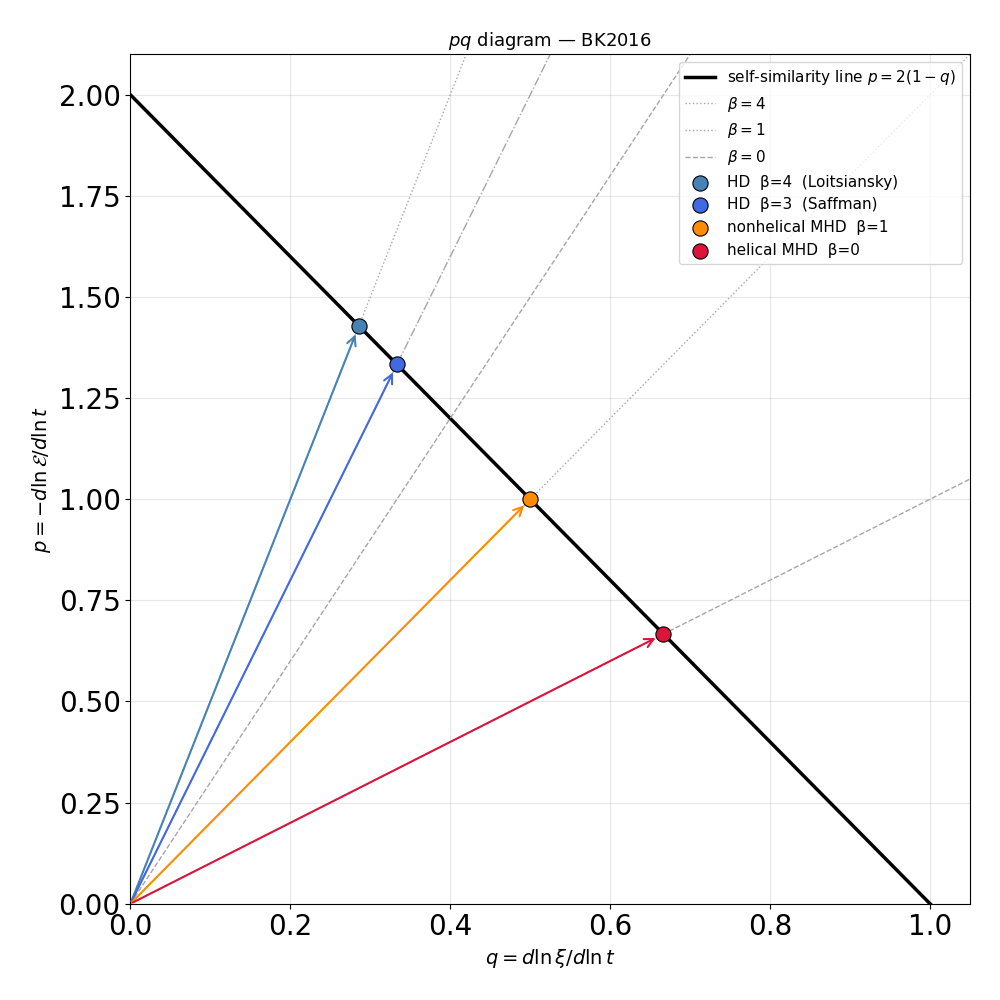

In [41]:
fig, ax = plt.subplots(figsize=(10, 10))

# ── self-similarity line  p = 2(1-q)  ─────────────────────────────────────
q_line = np.linspace(0.0, 1.1, 300)
p_ss   = 2.0 * (1.0 - q_line)
ax.plot(q_line, p_ss, 'k-', lw=2.5, label=r'self-similarity line $p=2(1-q)$', zorder=2)

# ── constant-beta lines  p = (1+beta)*q  ──────────────────────────────────
for beta_val, ls in [(4, ':'), (3, '-.'), (2, '--'), (1, ':'), (0, '--')]:
    q_b = np.linspace(0.0, 1.1, 200)
    p_b = (1 + beta_val) * q_b
    ax.plot(q_b, p_b, lw=1.0, ls=ls, color='0.65',
            label=fr'$\beta={beta_val}$' if beta_val in (4, 1, 0) else None)
    # label at q=0.9 or wherever in range
    q_label = 0.85
    p_label = (1 + beta_val) * q_label
    
# ── DNS fixed points ───────────────────────────────────────────────────────
for name, cls in CLASSES.items():
    q_fp = float(cls['q'])
    p_fp = float(cls['p'])
    ax.scatter([q_fp], [p_fp], s=120, color=cls['color'],
               zorder=5, edgecolors='k', lw=0.8, label=name)

    # schematic trajectory arrow: approach from higher p (lower q) along beta line
    q_start = q_fp * 0.0
    p_start = (1 + float(cls['beta'])) * q_start
    dq = q_fp - q_start
    dp = p_fp - p_start
    ax.annotate('', xy=(q_fp - 0.01*dq, p_fp - 0.01*dp),
                xytext=(q_start, p_start),
                arrowprops=dict(arrowstyle='->', color=cls['color'],
                                lw=1.5, mutation_scale=16))

ax.set_xlim(0, 1.05)
ax.set_ylim(0, 2.1)
ax.set_xlabel(r'$q = d\ln\xi/d\ln t$', fontsize=14)
ax.set_ylabel(r'$p = -d\ln\mathcal{E}/d\ln t$', fontsize=14)
ax.set_title(r'$pq$ diagram — BK2016', fontsize=13)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Energy decay and integral-scale growth

The total energy $\mathcal{E}(t) \propto (1+t/t_1)^{-p}$ and integral scale $\xi(t) \propto (1+t/t_1)^{q}$
evolve as power laws once $t \gg t_1$.  The ratio $p/q = 1+\beta$ is the slope of the
constant-$\beta$ line in the $pq$ diagram.


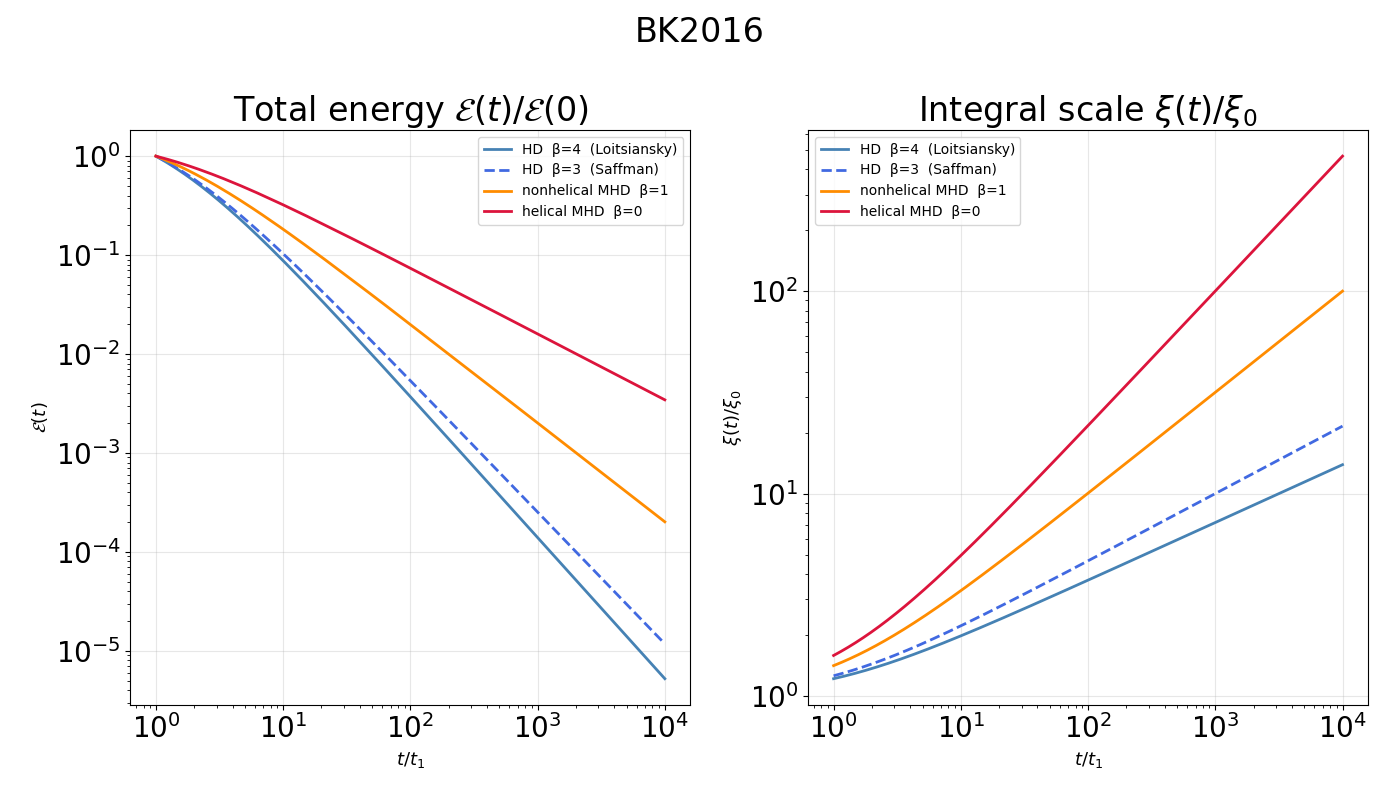

In [42]:
t_arr = np.logspace(0, 4, 4000)   # t/t1

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

for name, cls in CLASSES.items():
    q_exp = cls['q']
    p_exp = cls['p']
    color = cls['color']
    ls    = cls['ls']

    # total energy from E_spectrum integrated over k_grid (numerical)
    E_total = np.array([
        np.trapezoid(E_spectrum(k_grid, t, cls['beta'], q_exp, k0_init=1.0, s=4), k_grid)
        for t in t_arr
    ])
    xi_arr = xi_t(t_arr, q_exp)   # integral scale normalised to xi(0)=1

    axes[0].loglog(t_arr, E_total / E_total[0], color=color, ls=ls, lw=2, label=name)
    axes[1].loglog(t_arr, xi_arr,                color=color, ls=ls, lw=2, label=name)

# reference power-law slopes
for ax, label, exp_dict, col in [
    (axes[0], r'$\mathcal{E}(t)$',
     {r'$t^{-p}$': {n: -CLASSES[n]['p'] for n in CLASSES}}, 'k'),
    (axes[1], r'$\xi(t)/\xi_0$',
     {r'$t^{q}$': {n:  CLASSES[n]['q'] for n in CLASSES}}, 'k'),
]:
    ax.set_xlabel(r'$t/t_1$', fontsize=13)
    ax.set_ylabel(label, fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

axes[0].set_title(r'Total energy $\mathcal{E}(t)/\mathcal{E}(0)$')
axes[1].set_title(r'Integral scale $\xi(t)/\xi_0$')

plt.suptitle('BK2016')
plt.tight_layout()
plt.show()
